# Controlling an interferometer using EPICS and a stage using ophyd
awojdyla@lbl.gov, Feb 2026

In [1]:
# !pip install pyepics
# !pip install ophyd

In [1]:
#using base 3.13.5 on GW
import epics
import ophyd

## Reading the PV for the interferometer
We assume that an IOC is running for the Smaract interferomter, and that we can poll it through the network

In [2]:
epics.caget('CATERETE:PICOSCALE:POS_0')

-1000578663

In [3]:
# from time import sleep
# from matplotlib import pyplot as plt
# import numpy as np  

# p = epics.PV('CATERETE:PICOSCALE:POS_0')

# N_buffer = 100
# pos0_pm = np.zeros(N_buffer)
# t_s = np.zeros(N_buffer)
# for i in range(N_buffer):
# # Get the value and metadata in a dictionary
#     pvdata = p.get_with_metadata()
#     pos0_pm[i] = pvdata['value']
#     t_s[i] = pvdata['timestamp']
#     sleep(0.1)



In [4]:
# plt.plot(t_s,(pos0_pm-pos0_pm[0])*1e-3)
# plt.xlabel('Time (s)')
# plt.ylabel('Position (nm)')

## Moving the stage

### create an ophyd wrapper

In [5]:
from ophyd import Device, Component as Cpt, Signal
from ophyd.status import SubscriptionStatus
import threading
import time

class NewportXPSMotor(Device):
    # Ophyd signals
    user_readback = Cpt(Signal, value=0, kind='hinted')
    user_setpoint = Cpt(Signal, value=0, kind='normal')
    
    def __init__(self, ip_address, stage_name, username='Administrator', 
                 password='Administrator', *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        from newportxps import NewportXPS
        
        self.stage_name = stage_name
        self.group_name = stage_name.split('.')[0]  # Extract 'Group1' from 'Group1.Pos'
        self.xps = NewportXPS(ip_address, username=username, password=password)
        
        # Update initial position
        self._update_position()
        
    def _update_position(self):
        """Read current position from hardware"""
        pos = self.xps.read_stage_position(self.stage_name)
        self.user_readback.put(pos)
        return pos
    
    def _is_moving(self):
        """Check if the motor is currently moving"""
        status = self.xps.get_group_status()
        group_status = status.get(self.group_name, '')
        return 'Moving' in group_status
    
    def set(self, position, timeout=30):
        """Move to a position and return a status object"""
        
        def check_done(*, old_value, value, **kwargs):
            """Callback to check if motion is complete"""
            return not self._is_moving()
        
        # Start the move
        self.user_setpoint.put(position)
        self.xps.move_stage(self.stage_name, position)
        
        # Create a status object that monitors completion
        status = SubscriptionStatus(self.user_readback, check_done, timeout=timeout)
        
        # Start a background thread to update position during motion
        def monitor_motion():
            while not status.done:
                self._update_position()
                time.sleep(0.05)  # 50ms polling
            # Final position update
            self._update_position()
        
        thread = threading.Thread(target=monitor_motion, daemon=True)
        thread.start()
        
        return status
    
    def read(self):
        """Read current position"""
        pos = self._update_position()
        return {f'{self.name}_user_readback': {'value': pos, 'timestamp': time.time()}}
    
    def describe(self):
        """Describe the readback signal"""
        return {f'{self.name}_user_readback': {
            'source': f'XPS:{self.stage_name}',
            'dtype': 'number',
            'shape': []
        }}

In [6]:
import ophyd
from ophyd import EpicsSignal

#stock ophyd opbject for EPICS signal
interf = ophyd.EpicsSignal('CATERETE:PICOSCALE:POS_0', name='interferometer_position')

#custom ophyd object
motor = NewportXPSMotor(
    ip_address='192.168.10.20',
    stage_name='Group1.Pos',
    username='Administrator',
    password='Administrator',
    name='xps_motor'
)

pos_inter_m = interf.get()*1e-12
pos_readback_m = motor.get()[0]*1e-3
print(f"Interferometer position: {pos_inter_m*1e3} mm")
print(f"Motor readback position: {pos_readback_m*1e3} mm")


Interferometer position: -1.000578663 mm
Motor readback position: 5.498999000000001 mm




Transient Scan ID: 1     Time: 2026-03-17 15:37:44
Persistent Unique Scan ID: '5e95dd92-bce3-4f10-a282-bbc15a39b1a8'
New stream: 'primary'
+-----------+------------+-------------------------+-------------------------+
|   seq_num |       time | xps_motor_user_readback | interferometer_position |
+-----------+------------+-------------------------+-------------------------+
|         1 | 15:37:45.0 |                  -1.000 |              1112114289 |
|         2 | 15:37:45.1 |                  -0.980 |              1109075998 |
|         3 | 15:37:45.3 |                  -0.960 |              1131475769 |
|         4 | 15:37:45.4 |                  -0.940 |              1151046068 |
|         5 | 15:37:45.6 |                  -0.920 |              1168849615 |
|         6 | 15:37:45.7 |                  -0.900 |              1191412175 |
|         7 | 15:37:45.8 |                  -0.880 |              1211236057 |
|         8 | 15:37:46.0 |                  -0.860 |              122

('5e95dd92-bce3-4f10-a282-bbc15a39b1a8',)

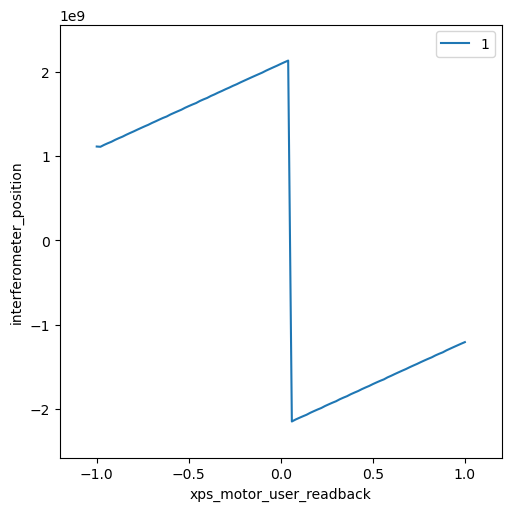

In [7]:
from bluesky import RunEngine
from bluesky.callbacks.best_effort import BestEffortCallback
import bluesky.plans as bp

RE = RunEngine()

# Add BestEffortCallback - shows table and live plots
bec = BestEffortCallback()
RE.subscribe(bec)

# Now run your scan
RE(bp.scan([interf, motor], motor, -1, 1, 101))



Transient Scan ID: 2     Time: 2026-03-11 15:03:55
Persistent Unique Scan ID: 'fb7aff59-2830-4851-8196-24f4649802b0'
New stream: 'primary'
+-----------+------------+-------------------------+
|   seq_num |       time | interferometer_position |
+-----------+------------+-------------------------+
|         1 | 15:03:55.1 |              1976846412 |
|         2 | 15:03:55.1 |              1976823301 |
|         3 | 15:03:55.2 |              1976822237 |
|         4 | 15:03:55.2 |              1976837062 |
|         5 | 15:03:55.3 |              1976846195 |
|         6 | 15:03:55.3 |              1976837626 |
|         7 | 15:03:55.4 |              1976849546 |
|         8 | 15:03:55.4 |              1976851535 |
|         9 | 15:03:55.5 |              1976846228 |
|        10 | 15:03:55.6 |              1976827568 |
|        11 | 15:03:55.6 |              1976828336 |
|        12 | 15:03:55.7 |              1976852033 |
|        13 | 15:03:55.7 |              1976839346 |
|        14

('fb7aff59-2830-4851-8196-24f4649802b0',)

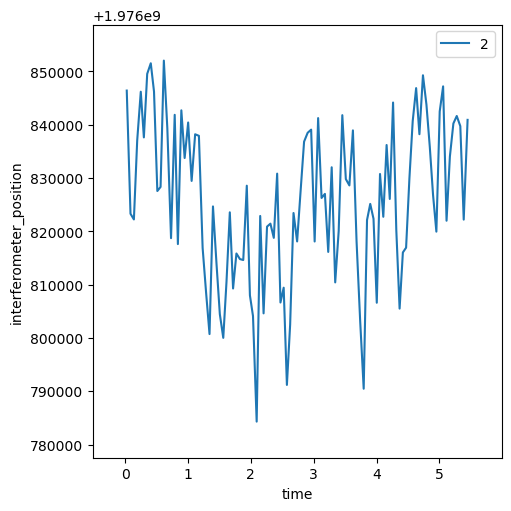

In [12]:
RE(bp.count([interf],101))

### using ophyd async